In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install transformers datasets scikit-learn

Enriched Datasets loaded successfully!
Tokenizing datasets and embedding linguistic features...


Map:   0%|          | 0/6037 [00:00<?, ? examples/s]

Map:   0%|          | 0/847 [00:00<?, ? examples/s]

Map:   0%|          | 0/711 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.381596,0.479372,0.809917,0.755690,0.766154,0.745509
2,0.215227,0.627044,0.814640,0.755070,0.788274,0.724551
3,0.114385,0.412279,0.881936,0.857143,0.819672,0.898204
4,0.087792,0.613185,0.876033,0.837209,0.868167,0.808383
5,0.043303,0.616623,0.879575,0.842105,0.871795,0.814371


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector


--- Evaluating on Test Set ---


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



--- Detailed Classification Report ---
              precision    recall  f1-score   support

   Clean (0)       0.98      0.85      0.91       505
   Fraud (1)       0.73      0.96      0.83       206

    accuracy                           0.88       711
   macro avg       0.85      0.90      0.87       711
weighted avg       0.91      0.88      0.89       711

Generating Confusion Matrix...
Saving the best hybrid model...
Done! You can download the model and confusion matrix from Kaggle Output.


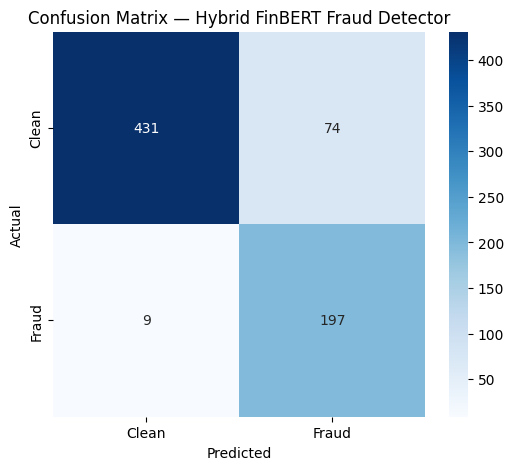

In [10]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# SETUP FOR KAGGLE ENVIRONMENT
# ---------------------------------------------------------
# UPDATE THIS with your Kaggle dataset path after uploading the new CSVs
INPUT_DIR = "/kaggle/input/your-dataset-name-here/"
OUTPUT_DIR = "/kaggle/working/hybrid-fraud-model"

try:
    train_df = pd.read_csv(os.path.join(INPUT_DIR, "/kaggle/input/datasets/shubhamp06/new-train-dataset/train_dataset.csv"))
    val_df = pd.read_csv(os.path.join(INPUT_DIR, "/kaggle/input/datasets/shubhamp06/new-train-dataset/val_dataset.csv"))
    test_df = pd.read_csv(os.path.join(INPUT_DIR, "/kaggle/input/datasets/shubhamp06/new-train-dataset/test_dataset.csv"))
    print("Enriched Datasets loaded successfully!")
except FileNotFoundError:
    print(f"Error: Could not find datasets in {INPUT_DIR}.")
    import sys
    sys.exit(1)

# List of the new linguistic features
LINGUISTIC_FEATURES = [
    'hedge_ratio', 'complexity_ratio', 'avg_sentence_len', 
    'unique_word_ratio', 'question_count', 'number_ratio'
]

# Convert Pandas DataFrames to HuggingFace Datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

# ---------------------------------------------------------
# MODEL & TOKENIZER INITIALIZATION
# ---------------------------------------------------------
MODEL_NAME = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ---------------------------------------------------------
# TOKENIZATION FUNCTION
# ---------------------------------------------------------
def tokenize_function(examples):
    # Tokenize text
    tokenized = tokenizer(
        examples["Text"], 
        padding="max_length", 
        truncation=True, 
        max_length=512
    )
    # Extract linguistic features into a tensor format
    ling_feats = []
    for i in range(len(examples['Text'])):
        feats = [examples[feat][i] for feat in LINGUISTIC_FEATURES]
        ling_feats.append(feats)
    
    tokenized['linguistic_features'] = ling_feats
    return tokenized

print("Tokenizing datasets and embedding linguistic features...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Rename 'Label' to 'labels'
tokenized_train = tokenized_train.rename_column("Label", "labels")
tokenized_val = tokenized_val.rename_column("Label", "labels")
tokenized_test = tokenized_test.rename_column("Label", "labels")

# Set the format to PyTorch tensors
columns_to_keep = ['input_ids', 'attention_mask', 'labels', 'linguistic_features']
if 'token_type_ids' in tokenized_train.column_names:
    columns_to_keep.append('token_type_ids')

tokenized_train.set_format("torch", columns=columns_to_keep)
tokenized_val.set_format("torch", columns=columns_to_keep)
tokenized_test.set_format("torch", columns=columns_to_keep)

# ---------------------------------------------------------
# HYBRID ARCHITECTURE (FinBERT + Linguistic Features)
# ---------------------------------------------------------
labels_array = train_df['Label'].values
class_weights = compute_class_weight('balanced', classes=np.unique(labels_array), y=labels_array)

class HybridFraudDetector(nn.Module):
    def __init__(self, n_linguistic_features=6):
        super().__init__()
        # Load the raw FinBERT without a classification head
        self.bert = AutoModel.from_pretrained("ProsusAI/finbert")
        
        # Register class weights as a buffer so DataParallel handles them correctly across multiple GPUs (like T4 x2)
        self.register_buffer('class_weights_tensor', torch.tensor(class_weights, dtype=torch.float32))
        
        # Neural network for linguistic features
        self.linguistic_proj = nn.Sequential(
            nn.Linear(n_linguistic_features, 64),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        
        # Final combined classifier
        self.classifier = nn.Sequential(
            nn.Linear(768 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )
        
    def forward(self, input_ids, attention_mask, linguistic_features, labels=None, token_type_ids=None):
        # 1. Get BERT embeddings
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        cls_embed = bert_out.last_hidden_state[:, 0, :] # Grab the [CLS] token representation
        
        # 2. Process linguistic features
        ling_embed = self.linguistic_proj(linguistic_features.float())
        
        # 3. Concatenate and Classify
        combined = torch.cat((cls_embed, ling_embed), dim=1)
        logits = self.classifier(combined)
        
        # 4. Calculate weighted loss
        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights_tensor)
            loss = loss_fn(logits, labels)
            
        # Trainer expects a tuple (loss, outputs) or an object with attributes
        return {"loss": loss, "logits": logits} if labels is not None else {"logits": logits}

model = HybridFraudDetector(n_linguistic_features=len(LINGUISTIC_FEATURES))

# ---------------------------------------------------------
# METRICS COMPUTATION
# ---------------------------------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # Handling tuple/dict outputs from the custom model
    if isinstance(logits, tuple):
        logits = logits[0]
    predictions = np.argmax(logits, axis=-1)
    
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

# ---------------------------------------------------------
# TRAINING SETUP
# ---------------------------------------------------------
# We don't need a CustomTrainer anymore because the HybridModel calculates its own weighted loss in the forward pass!
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,
    logging_dir="/kaggle/working/logs",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

# ---------------------------------------------------------
# EXECUTE TRAINING
# ---------------------------------------------------------
if __name__ == "__main__":
    print("Starting Hybrid Model Training...")
    trainer.train()

    print("\n--- Evaluating on Test Set ---")
    predictions = trainer.predict(tokenized_test)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids
    
    print("\n--- Detailed Classification Report ---")
    report = classification_report(labels, preds, target_names=["Clean (0)", "Fraud (1)"])
    print(report)

    # Generate Confusion Matrix
    print("Generating Confusion Matrix...")
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Clean', 'Fraud'], 
                yticklabels=['Clean', 'Fraud'])
    plt.title('Confusion Matrix — Hybrid FinBERT Fraud Detector')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.savefig('/kaggle/working/confusion_matrix.png')
    
    print("Saving the best hybrid model...")
    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "best_hybrid_model.pt"))
    print("Done! You can download the model and confusion matrix from Kaggle Output.")
